# Linear Regression using RFE

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
ww_df = pd.read_csv("C:/Users/ukhan/Documents/DataSet/OpenMesh/wireless_weather_signal_ph1_modelling_data.csv")

In [6]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'LATITUDE', 'LONGITUDE', 'WND_SPEED_MPS', 'WND_TYPE_CODE_C',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS', 'TMP_C',
       'DEW_TMP_C', 'SLP_HECTOPASCALS'],
      dtype='object')

In [7]:
ww_df.Datetime = pd.to_datetime(ww_df.Datetime)

In [8]:
ww_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512001 entries, 0 to 512000
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Datetime          512001 non-null  datetime64[ns]
 1   sublink_id        512001 non-null  int64         
 2   rsl_value         512001 non-null  float64       
 3   frequency         512001 non-null  int64         
 4   length            512001 non-null  float64       
 5   LATITUDE          512001 non-null  float64       
 6   LONGITUDE         512001 non-null  float64       
 7   WND_SPEED_MPS     512001 non-null  int64         
 8   WND_TYPE_CODE_C   512001 non-null  int64         
 9   WND_TYPE_CODE_N   512001 non-null  int64         
 10  WND_TYPE_CODE_V   512001 non-null  int64         
 11  VIS_DISTANCE_MTS  512001 non-null  int64         
 12  TMP_C             512001 non-null  float64       
 13  DEW_TMP_C         512001 non-null  int64         
 14  SLP_

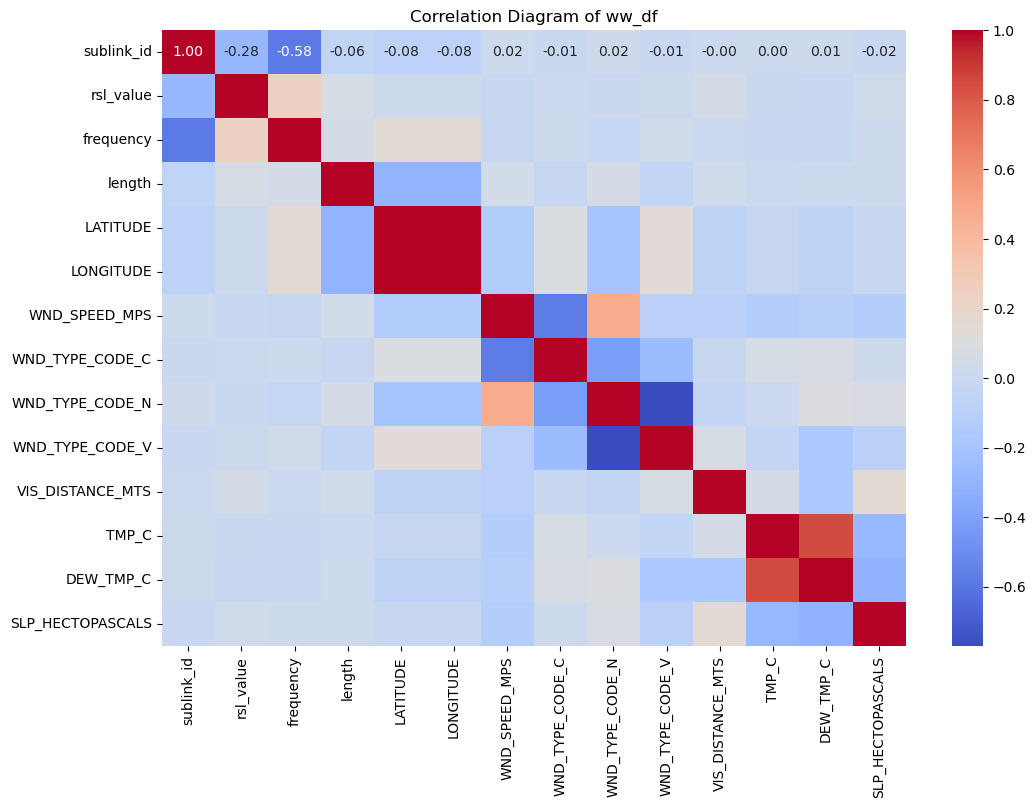

In [9]:
# Calculate the correlation matrix
correlation_matrix = ww_df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Diagram of ww_df')
plt.show()

In [10]:
ww_df.columns

Index(['Datetime', 'sublink_id', 'rsl_value', 'frequency', 'length',
       'LATITUDE', 'LONGITUDE', 'WND_SPEED_MPS', 'WND_TYPE_CODE_C',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS', 'TMP_C',
       'DEW_TMP_C', 'SLP_HECTOPASCALS'],
      dtype='object')

In [11]:
ww_df.drop(columns=['Datetime', 'sublink_id', 'frequency', 'LATITUDE', 'LONGITUDE'], inplace=True)

In [21]:
ww_df.columns

Index(['rsl_value', 'length', 'WND_SPEED_MPS', 'WND_TYPE_CODE_C',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS', 'TMP_C',
       'DEW_TMP_C', 'SLP_HECTOPASCALS'],
      dtype='object')

In [22]:
ww_df.shape

(512001, 10)

## Translate negative to positive for data inter-pretation

In [73]:
ww_df['TMP_K'] = ww_df['TMP_C']+273

In [74]:
ww_df['DEW_TMP_K'] = ww_df['DEW_TMP_C']+273

In [84]:
ww_df['rsl_value'] = ww_df['rsl_value']+100

In [79]:
ww_df.drop(columns=['TMP_C', 'DEW_TMP_C'], inplace=True)

In [103]:
ww_df = ww_df.reset_index(drop=True)

In [105]:
ww_df.isna().sum()

rsl_value           0
length              0
WND_SPEED_MPS       0
WND_TYPE_CODE_C     0
WND_TYPE_CODE_N     0
WND_TYPE_CODE_V     0
VIS_DISTANCE_MTS    0
SLP_HECTOPASCALS    0
TMP_K               0
DEW_TMP_K           0
dtype: int64

## Preprocessed DataSet for Multiple Linear Regression

In [183]:
ww_df.to_csv('C:/Users/ukhan/Documents/DataSet/OpenMesh/MLRDataset.csv', index=False)

In [106]:
from sklearn.model_selection import train_test_split

# We specify this so that the train and test data set always have the same rows, respectively
df_train, df_test = train_test_split(ww_df, train_size = 0.7, test_size = 0.3, random_state = 100)

In [107]:
df_train.columns

Index(['rsl_value', 'length', 'WND_SPEED_MPS', 'WND_TYPE_CODE_C',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS',
       'SLP_HECTOPASCALS', 'TMP_K', 'DEW_TMP_K'],
      dtype='object')

In [108]:
numerical_columns = ['rsl_value', 'length', 'WND_SPEED_MPS', 'VIS_DISTANCE_MTS', 'TMP_K', 'DEW_TMP_K', 'SLP_HECTOPASCALS']

In [109]:
df_train.describe()

,rsl_value,length,WND_SPEED_MPS,WND_TYPE_CODE_C,WND_TYPE_CODE_N,WND_TYPE_CODE_V,VIS_DISTANCE_MTS,SLP_HECTOPASCALS,TMP_K,DEW_TMP_K
count,358400.000000,358400.000000,358400.000000,358400.000000,358400.000000,358400.000000,358400.000000,358400.000000,358400.000000,358400.000000
mean,40.280140,1648.837133,28.842916,0.122121,0.558139,0.319741,15142.542539,10163.337394,283.477385,305.084788
std,7.590379,1332.090694,18.806650,0.327425,0.496609,0.466377,2767.940890,89.144253,7.800408,83.205819
min,9.000000,24.500000,0.000000,0.000000,0.000000,0.000000,402.000000,9823.000000,264.700000,79.000000
25%,36.000000,582.300000,15.000000,0.000000,0.000000,0.000000,16093.000000,10107.000000,278.000000,245.000000
50%,41.000000,1397.800000,26.000000,0.000000,1.000000,0.000000,16093.000000,10162.000000,281.900000,301.000000
75%,45.000000,2373.700000,36.000000,0.000000,1.000000,1.000000,16093.000000,10222.000000,288.600000,367.000000
max,81.000000,6936.500000,124.000000,1.000000,1.000000,1.000000,16093.000000,10399.000000,307.400000,517.000000


## Scaling
### Standard Scaler

In [110]:
from sklearn.preprocessing import StandardScaler
# Instantiate StandardScaler
scaler = StandardScaler()

In [136]:
np_train_scaled_numerical = scaler.fit_transform(df_train[numerical_columns])

In [137]:
np_train_scaled_numerical

array([[-2.0130959 , -0.27455912, -0.73606595, ..., -0.98422993,
        -0.98652839, -0.92364349],
       [ 0.49007641, -0.27455912, -0.73606595, ..., -0.56117457,
        -0.3134976 ,  0.79267819],
       [-0.43214497, -0.58797665,  1.49718972, ..., -0.06120006,
         0.68403018, -0.76659445],
       ...,
       [ 0.62182232, -0.12644587,  0.38056188, ..., -0.77911218,
        -1.32304378,  0.8824205 ],
       [-1.09087452,  0.13960245,  0.11469811, ..., -0.48425542,
         0.08310983, -2.30343151],
       [-1.09087452,  0.01828922, -0.41702943, ..., -0.62527387,
         0.14320187, -1.68645313]])

In [138]:
df_train_scaled_numerical = pd.DataFrame(np_train_scaled_numerical, columns=numerical_columns)

In [139]:
df_train_scaled_numerical.head()

,rsl_value,length,WND_SPEED_MPS,VIS_DISTANCE_MTS,TMP_K,DEW_TMP_K,SLP_HECTOPASCALS
0,-2.013096,-0.274559,-0.736066,0.343381,-0.984230,-0.986528,-0.923643
1,0.490076,-0.274559,-0.736066,0.343381,-0.561175,-0.313498,0.792678
2,-0.432145,-0.587977,1.497190,-1.982178,-0.061200,0.684030,-0.766594
3,0.358330,-0.587977,0.646426,0.343381,2.361753,1.813760,-0.878772
4,0.094839,-0.866111,-1.533657,0.343381,1.361804,1.549355,-0.183269


In [140]:
df_train_scaled_numerical.isna().sum()

rsl_value           0
length              0
WND_SPEED_MPS       0
VIS_DISTANCE_MTS    0
TMP_K               0
DEW_TMP_K           0
SLP_HECTOPASCALS    0
dtype: int64

In [141]:
df_train_scaled_numerical.shape

(358400, 7)

### Skip concatenation as it is bringing NaN into dataframe Cells

In [142]:
df_train[['WND_TYPE_CODE_C', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V']].index.duplicated().sum()

0

In [127]:
df_train_scaled_numerical = pd.concat([df_train_scaled_numerical, df_train[['WND_TYPE_CODE_C', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V']]], axis=1)

In [128]:
df_train_scaled_numerical.shape

(465858, 10)

In [129]:
df_train_scaled_numerical.isna().sum()

rsl_value           107458
length              107458
WND_SPEED_MPS       107458
VIS_DISTANCE_MTS    107458
TMP_K               107458
DEW_TMP_K           107458
SLP_HECTOPASCALS    107458
WND_TYPE_CODE_C     107458
WND_TYPE_CODE_N     107458
WND_TYPE_CODE_V     107458
dtype: int64

In [135]:
df_train_scaled_numerical.dropna().shape

(250942, 10)

In [49]:
df_train.shape, df_train.isna().sum()

((358400, 10),
 rsl_value           0
 length              0
 WND_SPEED_MPS       0
 WND_TYPE_CODE_C     0
 WND_TYPE_CODE_N     0
 WND_TYPE_CODE_V     0
 VIS_DISTANCE_MTS    0
 TMP_C               0
 DEW_TMP_C           0
 SLP_HECTOPASCALS    0
 dtype: int64)

In [143]:
df_train_scaled_numerical.shape, df_train_scaled_numerical.isna().sum()

((358400, 7),
 rsl_value           0
 length              0
 WND_SPEED_MPS       0
 VIS_DISTANCE_MTS    0
 TMP_K               0
 DEW_TMP_K           0
 SLP_HECTOPASCALS    0
 dtype: int64)

In [65]:
df_train_scaled_numerical[df_train_scaled_numerical.isna()].iloc[[0]]

,rsl_value,length,WND_SPEED_MPS,VIS_DISTANCE_MTS,TMP_C,DEW_TMP_C,SLP_HECTOPASCALS,WND_TYPE_CODE_C,WND_TYPE_CODE_N,WND_TYPE_CODE_V
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
df_train_scaled_numerical.describe()

,rsl_value,length,WND_SPEED_MPS,VIS_DISTANCE_MTS,TMP_C,DEW_TMP_C,SLP_HECTOPASCALS,WND_TYPE_CODE_C,WND_TYPE_CODE_N,WND_TYPE_CODE_V
count,3.584000e+05,3.584000e+05,3.584000e+05,3.584000e+05,3.584000e+05,3.584000e+05,3.584000e+05,250942.000000,250942.000000,250942.000000
mean,1.105267e-16,1.458456e-16,1.685160e-17,-1.248803e-16,-2.890347e-16,-2.910370e-17,6.645557e-15,0.125272,0.515800,0.358928
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,0.331028,0.499751,0.479687
min,-4.121030e+00,-1.219391e+00,-1.533657e+00,-5.325462e+00,-2.407234e+00,-2.717179e+00,-3.817833e+00,0.000000,0.000000,0.000000
25%,-5.638909e-01,-8.006502e-01,-7.360660e-01,3.433812e-01,-7.021930e-01,-7.221234e-01,-6.319810e-01,0.000000,0.000000,0.000000
50%,9.483868e-02,-1.884537e-01,-1.511657e-01,3.433812e-01,-2.022185e-01,-4.909264e-02,-1.500260e-02,0.000000,1.000000,0.000000
75%,6.218223e-01,5.441551e-01,3.805619e-01,3.433812e-01,6.567121e-01,7.441222e-01,6.580647e-01,0.000000,1.000000,1.000000
max,5.364675e+00,3.969452e+00,5.059764e+00,3.433812e-01,3.066846e+00,2.546883e+00,2.643613e+00,1.000000,1.000000,1.000000


In [51]:
df_train_scaled_numerical.head()

,rsl_value,length,WND_SPEED_MPS,VIS_DISTANCE_MTS,TMP_C,DEW_TMP_C,SLP_HECTOPASCALS,WND_TYPE_CODE_C,WND_TYPE_CODE_N,WND_TYPE_CODE_V
0,-2.013096,-0.274559,-0.736066,0.343381,-0.984230,-0.986528,-0.923643,0.0,1.0,0.0
1,0.490076,-0.274559,-0.736066,0.343381,-0.561175,-0.313498,0.792678,0.0,1.0,0.0
2,-0.432145,-0.587977,1.497190,-1.982178,-0.061200,0.684030,-0.766594,0.0,1.0,0.0
3,0.358330,-0.587977,0.646426,0.343381,2.361753,1.813760,-0.878772,0.0,1.0,0.0
4,0.094839,-0.866111,-1.533657,0.343381,1.361804,1.549355,-0.183269,0.0,1.0,0.0


In [58]:
df_train_scaled_numerical.iloc[[0,1]]

,rsl_value,length,WND_SPEED_MPS,VIS_DISTANCE_MTS,TMP_C,DEW_TMP_C,SLP_HECTOPASCALS,WND_TYPE_CODE_C,WND_TYPE_CODE_N,WND_TYPE_CODE_V
0,-2.013096,-0.274559,-0.736066,0.343381,-0.984230,-0.986528,-0.923643,0.0,1.0,0.0
1,0.490076,-0.274559,-0.736066,0.343381,-0.561175,-0.313498,0.792678,0.0,1.0,0.0


In [144]:
df_train_scaled_numerical.shape, df_test.shape

((358400, 7), (153601, 10))

In [145]:
df_test = df_test[numerical_columns]

In [146]:
df_train_scaled_numerical.shape, df_test.shape

((358400, 7), (153601, 7))

## Simple Linear Regression

In [147]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm # Used for F-statistic
import numpy as np # Import numpy for sqrt

### Reference Code for standard scaling and converting to dataframe. train_test_split using X and y 

In [ ]:
# Sort the DataFrame by Datetime for time-series splitting
merged_df = merged_df.sort_values('Datetime')

# Identify numerical columns
numerical_cols = df_train_numerical.select_dtypes(include=['float64', 'int64']).columns
print(numerical_cols)

scaler = StandardScaler()

# Fit and transform the numerical columns
df_train_scaled_numerical = scaler.fit_transform(df_train_numerical[numerical_cols])

# Create a new DataFrame with scaled numerical data and the Datetime column
df_train_scaled = pd.DataFrame(df_train_scaled_numerical, columns=numerical_cols)

display(df_train_scaled.head())

In [153]:
ww_df.columns

Index(['rsl_value', 'length', 'WND_SPEED_MPS', 'WND_TYPE_CODE_C',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS',
       'SLP_HECTOPASCALS', 'TMP_K', 'DEW_TMP_K'],
      dtype='object')

In [154]:
ww_df.drop(columns=['WND_TYPE_CODE_C', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V'], inplace=True)

In [155]:
# Define features (X) and target (y)
# Drop 'Datetime' as it's not a feature for the model, and 'rsl_value' is the target
X = ww_df.drop(columns=['rsl_value'])
y = ww_df['rsl_value']

In [156]:
# Split data into training and testing sets (80:20 ratio)
# Shuffle is set to False for time-series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [157]:
X_train[['WND_TYPE_CODE_C', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V']].value_counts()

KeyError: "None of [Index(['WND_TYPE_CODE_C', 'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V'], dtype='object')] are in the [columns]"

In [158]:
ww_df.columns

Index(['rsl_value', 'length', 'WND_SPEED_MPS', 'VIS_DISTANCE_MTS',
       'SLP_HECTOPASCALS', 'TMP_K', 'DEW_TMP_K'],
      dtype='object')

In [160]:
numerical_columns = X_train.select_dtypes(include=['float64', 'int64']).columns

In [161]:
#numerical_columns = ['length', 'WND_SPEED_MPS', 'VIS_DISTANCE_MTS', 'TMP_C', 'DEW_TMP_C', 'SLP_HECTOPASCALS']
numerical_columns

Index(['length', 'WND_SPEED_MPS', 'VIS_DISTANCE_MTS', 'SLP_HECTOPASCALS',
       'TMP_K', 'DEW_TMP_K'],
      dtype='object')

In [166]:
y_train.values.reshape(-1,1)

array([[35.],
       [41.],
       [39.],
       ...,
       [30.],
       [50.],
       [39.]])

In [167]:
# Scale features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train[numerical_columns])
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

In [170]:
X_train.shape, y_train.shape

((409600, 6), (409600,))

### Simple Linear Regression
- Using df_train_scaled_numerical, df_test (7 columns)

In [148]:
df_train_scaled_numerical.shape, df_test.shape

((358400, 7), (153601, 7))

In [149]:
## X_train_scaled, y_train_scaled from df_train_scaled_numerical 
X_train_scaled = df_train_scaled_numerical.drop(columns=['rsl_value'])
y_train_scaled = df_train_scaled_numerical['rsl_value']

In [168]:
# Instantiate and train Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

LinearRegression()

In [174]:
# Make predictions on the scaled test data
y_train_pred_scaled = model.predict(X_train_scaled)

# Inverse transform the scaled predictions to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)

In [175]:
# Calculate regression metrics
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train) # Calculate RMSE by taking the square root of MSE
r_squared_train = r2_score(y_train, y_train_pred)

In [176]:
# Calculate F-statistic using statsmodels (requires adding a constant)
X_train_scaled_with_constant = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train_scaled, X_train_scaled_with_constant).fit()
f_statistic = ols_model.fvalue

print(f"MSE: {mse_train}")
print(f"RMSE: {rmse_train}")
print(f"R-squared: {r_squared_train}")
print(f"F-statistic: {f_statistic}")

MSE: 55.97876527375973
RMSE: 7.481895834196018
R-squared: 0.007448454145324801
F-statistic: 512.2882016367703


In [177]:
X_test_scaled = scaler_X.transform(X_test) # Use the scaler fitted on training data
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)) # Use the scaler fitted on training data

In [178]:
# Calculate F-statistic using statsmodels (requires adding a constant)
X_test_scaled_with_constant = sm.add_constant(X_test_scaled)
ols_model = sm.OLS(y_test_scaled, X_test_scaled_with_constant).fit()
f_test_statistic = ols_model.fvalue

print(f"F-statistic: {f_test_statistic}")

F-statistic: 234.42151332937195


In [179]:
# Make predictions on the scaled test data
y_test_pred_scaled = model.predict(X_test_scaled)

# Inverse transform the scaled predictions to original scale
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

In [180]:
# Calculate regression metrics
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test) # Calculate RMSE by taking the square root of MSE
r_squared_test = r2_score(y_test, y_test_pred)

In [181]:
print(f"MSE: {mse_test}")
print(f"RMSE: {rmse_test}")
print(f"R-squared: {r_squared_test}")
print(f"F-statistic: {f_test_statistic}")

MSE: 61.531176026352526
RMSE: 7.84418102967751
R-squared: 0.010242638366613988
F-statistic: 234.42151332937195


In [182]:
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     234.4
Date:                Mon, 17 Nov 2025   Prob (F-statistic):          1.09e-298
Time:                        16:35:09   Log-Likelihood:            -1.4959e+05
No. Observations:              102401   AIC:                         2.992e+05
Df Residuals:                  102394   BIC:                         2.993e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0826      0.010     -8.168      0.000      -0.102      -0.063
x1             0.1008      0.003     32.616      0.000       0.095       0.107
x2            -0.0112      0.004     -3.001      0.003      -0.019      -0.004
x3             0.0583      0.004     12.958      0.000       0.049       0.067
x4             0.0203      0.005      4.268      0.000       0.011       0.030
x5             0.0272      0.005      5.943      0.000       0.018       0.036
x6            -0.0126      0.006     -2.033      0.042      -0.025      -0.000
==============================================================================
Omnibus:                     6874.317   Durbin-Watson:                   1.925
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15097.069
Skew:                           0.443   Prob(JB):                         0.00
Kurtosis:                       4.660   Cond. No.                         10.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [1]:
from sklearn.model_selection import train_test_split

# We specify this so that the train and test data set always have the same rows, respectively
df_train, df_test = train_test_split(ww_df, train_size = 0.7, test_size = 0.3, random_state = 100)

NameError: name 'ww_df' is not defined

In [81]:
df_train.columns

Index(['rsl_value', 'length', 'WND_SPEED_MPS', 'WND_TYPE_CODE_C',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS', 'TMP_C',
       'DEW_TMP_C', 'SLP_HECTOPASCALS'],
      dtype='object')

In [84]:
from sklearn.preprocessing import StandardScaler
# Instantiate StandardScaler
scaler = StandardScaler()

In [85]:
df_train_numerical = df_train.copy()

In [86]:
# Identify numerical columns
numerical_cols = df_train_numerical.select_dtypes(include=['float64', 'int64']).columns
print(numerical_cols)

Index(['rsl_value', 'length', 'WND_SPEED_MPS', 'WND_TYPE_CODE_C',
       'WND_TYPE_CODE_N', 'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS', 'TMP_C',
       'DEW_TMP_C', 'SLP_HECTOPASCALS'],
      dtype='object')


In [87]:
# Fit and transform the numerical columns
df_train_scaled_numerical = scaler.fit_transform(df_train_numerical[numerical_cols])

# Create a new DataFrame with scaled numerical data and the Datetime column
df_train_scaled = pd.DataFrame(df_train_scaled_numerical, columns=numerical_cols)

display(df_train_scaled.head())

,rsl_value,length,WND_SPEED_MPS,WND_TYPE_CODE_C,WND_TYPE_CODE_N,WND_TYPE_CODE_V,VIS_DISTANCE_MTS,TMP_C,DEW_TMP_C,SLP_HECTOPASCALS
0,-2.013096,-0.274559,-0.736066,-0.372973,-1.123902,1.458608,0.343381,-0.984230,-0.986528,-0.923643
1,0.490076,-0.274559,-0.736066,-0.372973,0.889758,-0.685585,0.343381,-0.561175,-0.313498,0.792678
2,-0.432145,-0.587977,1.497190,-0.372973,0.889758,-0.685585,-1.982178,-0.061200,0.684030,-0.766594
3,0.358330,-0.587977,0.646426,-0.372973,0.889758,-0.685585,0.343381,2.361753,1.813760,-0.878772
4,0.094839,-0.866111,-1.533657,2.681162,-1.123902,-0.685585,0.343381,1.361804,1.549355,-0.183269


# Feature Elimination using RFE

In [42]:
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [43]:
# Split data into training and testing sets (80:20 ratio)
# Shuffle is set to False for time-series data
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((409600, 9), (102401, 9), (409600,), (102401,))

In [50]:
from sklearn.preprocessing import MinMaxScaler

In [51]:
scaler = MinMaxScaler()

In [72]:
X_train.columns

Index(['length', 'WND_SPEED_MPS', 'WND_TYPE_CODE_C', 'WND_TYPE_CODE_N',
       'WND_TYPE_CODE_V', 'VIS_DISTANCE_MTS', 'TMP_C', 'DEW_TMP_C',
       'SLP_HECTOPASCALS'],
      dtype='object')

In [74]:
X_train.describe()

,length,WND_SPEED_MPS,WND_TYPE_CODE_C,WND_TYPE_CODE_N,WND_TYPE_CODE_V,VIS_DISTANCE_MTS,TMP_C,DEW_TMP_C,SLP_HECTOPASCALS
count,409600.000000,409600.000000,409600.000000,409600.000000,409600.000000,409600.000000,409600.000000,409600.000000,409600.000000
mean,1604.410020,29.259814,0.122019,0.534597,0.343384,15059.994048,7.951203,6.786143,10170.537634
std,1316.635527,19.162696,0.327308,0.498802,0.474839,2876.562996,6.042774,70.119640,92.995449
min,24.500000,0.000000,0.000000,0.000000,0.000000,402.000000,-8.300000,-194.000000,9823.000000
25%,570.400000,15.000000,0.000000,0.000000,0.000000,16093.000000,3.900000,-44.000000,10110.000000
50%,1355.500000,26.000000,0.000000,1.000000,0.000000,16093.000000,7.200000,6.000000,10170.000000
75%,2216.400000,41.000000,0.000000,1.000000,1.000000,16093.000000,11.100000,56.000000,10233.000000
max,6936.500000,124.000000,1.000000,1.000000,1.000000,16093.000000,33.900000,244.000000,10399.000000


In [76]:
## Apply minMax scaler for non boolean columns
# Identify numerical columns
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_cols])

In [77]:
X_train_scaled = pd.DataFrame(X_train_scaled_numerical, columns=numerical_cols)

0        -65.0
1        -59.0
2        -61.0
3        -56.0
4        -58.0
          ... 
409595   -59.0
409596   -68.0
409597   -70.0
409598   -50.0
409599   -61.0
Name: rsl_value, Length: 409600, dtype: float64

In [59]:
# Scale features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

In [60]:
# Running RFE with the output number of the variable equal to 10
lm = LinearRegression()
lm.fit(X_train_scaled, y_train_scaled)

rfe = RFE(lm, step=15)             # running RFE
rfe = rfe.fit(X_train_scaled, y_train_scaled)

In [71]:
X_train_scaled.

<function ndarray.argmin>

In [46]:
list(zip(X_train_scaled.columns,rfe.support_,rfe.ranking_))

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [145]:
col = X_train_df.columns[rfe.support_]
col

Index(['yr', 'temp', 'atemp', 'hum', 'windspeed', 'season_2', 'season_3',
       'season_4', 'mnth_3', 'mnth_5', 'mnth_9', 'weekday_6', 'weathersit_2',
       'weathersit_3'],
      dtype='object')

In [146]:
X_train_df.columns[~rfe.support_]

Index(['holiday', 'workingday', 'mnth_2', 'mnth_4', 'mnth_6', 'mnth_7',
       'mnth_8', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_1', 'weekday_2',
       'weekday_3', 'weekday_4', 'weekday_5'],
      dtype='object')

In [147]:
X_train_rfe_df = X_train_df[col]

## Build Linear Regression Model using statsmodel

In [148]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#### Build Stats model with casual parameter as independent variable and cnt as dependent variable

In [149]:
import statsmodels.api as sm

# Add a constant
X_train_lm = sm.add_constant(X_train_rfe_df['temp'])

# Create a first fitted model
lr = sm.OLS(y_train_df, X_train_lm).fit()

In [150]:
lr.params

const    0.177060
temp     0.622792
dtype: float64

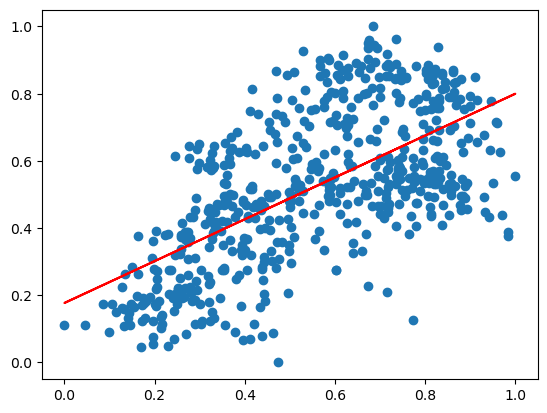

In [151]:
plt.scatter(X_train_lm.iloc[:, 1], y_train_df)
plt.plot(X_train_lm.iloc[:, 1], 0.177060 + 0.622792*X_train_lm.iloc[:, 1], 'r')
plt.show()

In [152]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     381.5
Date:                Wed, 04 Sep 2024   Prob (F-statistic):           1.04e-65
Time:                        08:33:24   Log-Likelihood:                 190.34
No. Observations:                 584   AIC:                            -376.7
Df Residuals:                     582   BIC:                            -367.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1771      0.019      9.310      0.0

## R-square value is 0.396 which is significantly low, let's try to optimize the features list further

In [153]:
# API to build model, print lr.params, plot lm (if plot enabled), print lr.summary 
def build_lr_model_using_statsmodel(title="Building Linear Regression Model", X_train_df=None, y_train_df=None, enable_plot=True):
    print(title + " Using Stats Model")
    # Add a constant
    X_train_lm = sm.add_constant(X_train_df)

    # Create a first fitted model
    lr = sm.OLS(y_train_df, X_train_lm).fit()
    #print("Linear Model for X_traindf.columns {%s} vs y_train_df.columns {%s}" %(str(X_train_df.columns), str(y_train_df.columns)))
    print(lr.params)
    if enable_plot:
        plt.scatter(X_train_lm.iloc[:, 1], y_train_df)
        plt.plot(X_train_lm.iloc[:, 1], dict(lr.params)['const'] + dict(lr.params)[X_train_df.name]*X_train_lm.iloc[:, 1], 'r')
        plt.show()

    print(lr.summary())
    return lr, X_train_lm

In [154]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
def get_feature_vif(X_train_df):
    vif = pd.DataFrame()
    vif['Features'] = X_train_df.columns
    vif['VIF'] = [variance_inflation_factor(X_train_df.values, i) for i in range(X_train_df.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    print(vif)
    return vif

## Model building with only 'atemp' features 

Linear Regression Model for atemp vs cnt Using Stats Model
const    0.164443
atemp    0.675420
dtype: float64


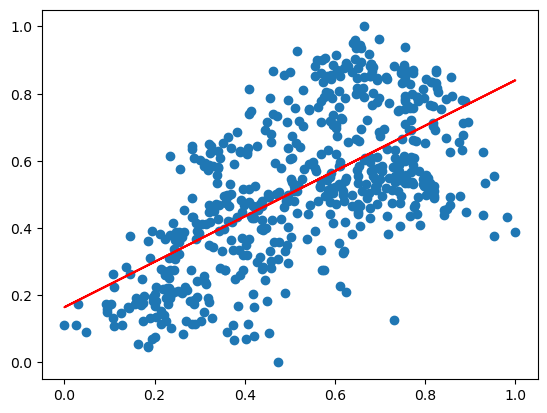

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     399.6
Date:                Wed, 04 Sep 2024   Prob (F-statistic):           4.44e-68
Time:                        08:34:04   Log-Likelihood:                 195.81
No. Observations:                 584   AIC:                            -387.6
Df Residuals:                     582   BIC:                            -378.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1644      0.019      8.564      0.0

In [155]:
title="Linear Regression Model for atemp vs cnt"
lr_atemp, X_train_lm_atemp = build_lr_model_using_statsmodel(title=title, X_train_df=X_train_rfe_df['atemp'], y_train_df=y_train_df)

### R-2 is reduced to 0.407, it is not a good mode fit

## Model Build: Combining 2 independent variables 'windspeed' and 'temp'

In [156]:
title="Linear Regression Model for 'windspeed' and 'temp' vs cnt"
lr_casual_atemp, X_train_casual_atemp_lm = build_lr_model_using_statsmodel(title=title, X_train_df=X_train_rfe_df[['windspeed', 'temp']], y_train_df=y_train_df, enable_plot=False)

Linear Regression Model for 'windspeed' and 'temp' vs cnt Using Stats Model
const        0.263443
windspeed   -0.178787
temp         0.599081
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     208.2
Date:                Wed, 04 Sep 2024   Prob (F-statistic):           6.57e-69
Time:                        08:34:59   Log-Likelihood:                 200.97
No. Observations:                 584   AIC:                            -395.9
Df Residuals:                     581   BIC:                            -382.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t

### R-2 is increased to 0.418, improved by using 2 features 'windspeed' and 'temp' feature parameter 

## Model building with all the features selected after RFE (Recursive Feature Elimination)

In [157]:
title="Linear Regression Model with all the paramters vs cnt"
lr_model1, X_train_lm1 = build_lr_model_using_statsmodel(title=title, X_train_df=X_train_rfe_df, y_train_df=y_train_df, enable_plot=False)

Linear Regression Model with all the paramters vs cnt Using Stats Model
const           0.203559
yr              0.225787
temp            0.255407
atemp           0.246657
hum            -0.173899
windspeed      -0.129621
season_2        0.130680
season_3        0.085661
season_4        0.184809
mnth_3          0.057368
mnth_5          0.030886
mnth_9          0.092675
weekday_6       0.024118
weathersit_2   -0.045861
weathersit_3   -0.223887
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     194.8
Date:                Wed, 04 Sep 2024   Prob (F-statistic):          2.31e-206
Time:                        08:35:33   Log-Likelihood:                 556.10
No. Observations:                 584   AIC:                    

In [158]:
vif = get_feature_vif(X_train_rfe_df)

        Features      VIF
2          atemp  1296.70
1           temp  1281.28
3            hum    17.08
6       season_3     7.55
4      windspeed     4.88
5       season_2     4.14
7       season_4     2.95
12  weathersit_2     2.14
0             yr     2.02
9         mnth_5     1.67
10        mnth_9     1.29
13  weathersit_3     1.25
8         mnth_3     1.19
11     weekday_6     1.17


### R-2 is increased to 0.827 with 14 features in the dataset 
## Let's try reducing the feature and see if the model still works with higher accuracy

### 'atemp' Drop features with High p-value and High VIF
- feature : p-value   VIF
- atemp     0.321     1296.7
## Build Model after eliminating 'atemp' feature

In [159]:
X_train_rfe_df = X_train_rfe_df.drop(columns='atemp', axis=1)

In [160]:
title="Linear Regression Model after dropping atemp feature vs cnt"
lr_model2, X_train_lm2 = build_lr_model_using_statsmodel(title=title, X_train_df=X_train_rfe_df, y_train_df=y_train_df, enable_plot=False)

Linear Regression Model after dropping atemp feature vs cnt Using Stats Model
const           0.205229
yr              0.226077
temp            0.486439
hum            -0.168654
windspeed      -0.135457
season_2        0.131847
season_3        0.084247
season_4        0.186588
mnth_3          0.057966
mnth_5          0.030375
mnth_9          0.091707
weekday_6       0.024053
weathersit_2   -0.046948
weathersit_3   -0.227806
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     209.7
Date:                Wed, 04 Sep 2024   Prob (F-statistic):          2.55e-207
Time:                        08:36:32   Log-Likelihood:                 555.59
No. Observations:                 584   AIC:                            -1083.
Df R

In [161]:
vif = get_feature_vif(X_train_rfe_df)

        Features    VIF
1           temp  23.57
2            hum  15.64
5       season_3   7.51
3      windspeed   4.54
4       season_2   4.12
6       season_4   2.89
11  weathersit_2   2.10
0             yr   2.01
8         mnth_5   1.66
9         mnth_9   1.29
12  weathersit_3   1.21
7         mnth_3   1.19
10     weekday_6   1.17


### R-2 is increased to 0.827 with 13 features in the dataset 
## Let's try reducing the feature and see if the model still works with higher accuracy

### Drop weekday_3 feature with high P-value
- mnth_5       P-Value=0.075
## Build Model after eliminating 'mnth_5' feature

In [162]:
X_train_rfe_df = X_train_rfe_df.drop(columns='mnth_5', axis=1)

In [163]:
title="Linear Regression Model after dropping mnth_5 feature vs cnt"
lm_model3, X_train_lm3 = build_lr_model_using_statsmodel(title=title, X_train_df=X_train_rfe_df, y_train_df=y_train_df, enable_plot=False)

Linear Regression Model after dropping mnth_5 feature vs cnt Using Stats Model
const           0.199654
yr              0.226210
temp            0.494514
hum            -0.160236
windspeed      -0.137044
season_2        0.139419
season_3        0.078686
season_4        0.183632
mnth_3          0.053103
mnth_9          0.091311
weekday_6       0.023934
weathersit_2   -0.047812
weathersit_3   -0.230755
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     226.1
Date:                Wed, 04 Sep 2024   Prob (F-statistic):          8.08e-208
Time:                        08:37:41   Log-Likelihood:                 553.96
No. Observations:                 584   AIC:                            -1082.
Df Residuals:               

In [164]:
vif = get_feature_vif(X_train_rfe_df)

        Features    VIF
1           temp  23.25
2            hum  15.57
5       season_3   7.36
3      windspeed   4.47
4       season_2   3.82
6       season_4   2.84
10  weathersit_2   2.10
0             yr   2.01
8         mnth_9   1.29
11  weathersit_3   1.21
9      weekday_6   1.17
7         mnth_3   1.15


### R-2 is increased to 0.826 with 12 features in the dataset 
## Let's try reducing the feature and see if the model still works with higher accuracy

# Drop hum feature with high P-value
- weekday_6          P-Value=0.033  VIF=1.17
## Build Model after eliminating 'weekday_6' feature

In [165]:
X_train_rfe_df = X_train_rfe_df.drop(columns='weekday_6', axis=1)

In [166]:
title="Linear Regression Model after dropping weekday_6 feature vs cnt"
lr_model4, X_train_lm4 = build_lr_model_using_statsmodel(title=title, X_train_df=X_train_rfe_df, y_train_df=y_train_df, enable_plot=False)

Linear Regression Model after dropping weekday_6 feature vs cnt Using Stats Model
const           0.205076
yr              0.226494
temp            0.490726
hum            -0.161026
windspeed      -0.136796
season_2        0.140236
season_3        0.079978
season_4        0.183633
mnth_3          0.051023
mnth_9          0.090771
weathersit_2   -0.047938
weathersit_3   -0.228999
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     244.7
Date:                Wed, 04 Sep 2024   Prob (F-statistic):          4.81e-208
Time:                        08:39:04   Log-Likelihood:                 551.65
No. Observations:                 584   AIC:                            -1079.
Df Residuals:                     572   BIC:      

In [167]:
vif = get_feature_vif(X_train_rfe_df)

        Features    VIF
1           temp  23.22
2            hum  15.43
5       season_3   7.35
3      windspeed   4.44
4       season_2   3.82
6       season_4   2.84
9   weathersit_2   2.09
0             yr   2.01
8         mnth_9   1.29
10  weathersit_3   1.21
7         mnth_3   1.15


### R-2 dropped to 0.825 with 11 features in the dataset. Not dropped significantly can continue further

### Drop feature with high P value and High VIF
- mnth_3 P-value=0.002, VIF=1.15
## Build Model after eliminating 'mnth_3' feature

In [168]:
X_train_rfe_df = X_train_rfe_df.drop(columns='mnth_3', axis=1)

In [169]:
title="Linear Regression Model after dropping mnth_3 feature vs cnt"
lr_model5, X_train_lm5 = build_lr_model_using_statsmodel(title=title, X_train_df=X_train_rfe_df, y_train_df=y_train_df, enable_plot=False)

Linear Regression Model after dropping mnth_3 feature vs cnt Using Stats Model
const           0.218268
yr              0.226654
temp            0.491753
hum            -0.168027
windspeed      -0.140308
season_2        0.136630
season_3        0.070943
season_4        0.174793
mnth_9          0.090940
weathersit_2   -0.045474
weathersit_3   -0.223148
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     264.4
Date:                Wed, 04 Sep 2024   Prob (F-statistic):          2.82e-207
Time:                        08:40:17   Log-Likelihood:                 546.95
No. Observations:                 584   AIC:                            -1072.
Df Residuals:                     573   BIC:                            -1024.

In [170]:
vif = get_feature_vif(X_train_rfe_df)

       Features    VIF
1          temp  23.17
2           hum  15.29
5      season_3   7.18
3     windspeed   4.43
4      season_2   3.79
6      season_4   2.71
8  weathersit_2   2.09
0            yr   2.00
7        mnth_9   1.29
9  weathersit_3   1.21


### R-2 dropped to 0.822 with 10 features in the dataset. Not dropped significantly can continue further

### Drop feature with high P value and High VIF
- season_3 P-value=0.001, VIF=7.18
## Build Model after eliminating 'season_3' feature

In [171]:
X_train_rfe_df = X_train_rfe_df.drop(columns='season_3', axis=1)

In [172]:
title="Linear Regression Model after dropping season_3 feature vs cnt"
lr_model6, X_train_lm6 = build_lr_model_using_statsmodel(title=title, X_train_df=X_train_rfe_df, y_train_df=y_train_df, enable_plot=False)

Linear Regression Model after dropping season_3 feature vs cnt Using Stats Model
const           0.210526
yr              0.224861
temp            0.582965
hum            -0.178745
windspeed      -0.141131
season_2        0.096458
season_4        0.147198
mnth_9          0.103330
weathersit_2   -0.044376
weathersit_3   -0.217575
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     287.1
Date:                Wed, 04 Sep 2024   Prob (F-statistic):          5.42e-206
Time:                        08:41:23   Log-Likelihood:                 541.01
No. Observations:                 584   AIC:                            -1062.
Df Residuals:                     574   BIC:                            -1018.
Df Model:             

In [173]:
vif = get_feature_vif(X_train_rfe_df)

       Features    VIF
2           hum  14.42
1          temp   7.78
3     windspeed   4.41
7  weathersit_2   2.09
0            yr   1.99
5      season_4   1.65
4      season_2   1.62
6        mnth_9   1.21
8  weathersit_3   1.20


### R-2 dropped to 0.818 with 9 features in the dataset. Not dropped significantly can continue further

### Drop feature with high P value and high VIF
- hum P-value=0 VIF=14.42
## Build Model after eliminating 'hum' feature

In [174]:
X_train_rfe_df = X_train_rfe_df.drop(columns='hum', axis=1)

In [177]:
title="Linear Regression Model after dropping hum feature vs cnt"
lr_model7, X_train_lm7 = build_lr_model_using_statsmodel(title=title, X_train_df=X_train_rfe_df, y_train_df=y_train_df, enable_plot=False)

Linear Regression Model after dropping hum feature vs cnt Using Stats Model
const           0.103681
yr              0.230145
temp            0.565537
windspeed      -0.111331
season_2        0.094440
season_4        0.138819
mnth_9          0.093575
weathersit_2   -0.073949
weathersit_3   -0.270972
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     308.4
Date:                Wed, 04 Sep 2024   Prob (F-statistic):          2.06e-202
Time:                        08:45:19   Log-Likelihood:                 529.64
No. Observations:                 584   AIC:                            -1041.
Df Residuals:                     575   BIC:                            -1002.
Df Model:                           8               

In [178]:
vif = get_feature_vif(X_train_rfe_df)

       Features   VIF
1          temp  3.98
2     windspeed  3.63
0            yr  1.97
3      season_2  1.61
6  weathersit_2  1.51
4      season_4  1.39
5        mnth_9  1.21
7  weathersit_3  1.10


### R-2 dropped to 0.811 with 8 features in the dataset. 
### Final Model still close to 1st model which has R2-score=0.827and 11 features

## Final Model summary:
- R-2 = 0.811 and F-score = 308.4
-                                                        **Parameters and coeeficients**

|sl |feature        | coeff       | Remarks         |
|:--|:--------------|:------------|:----------------|
|1. |const          | 0.103681    |                 |
|2. |yr             | 0.230145    |                 |
|3. |temp           | 0.565537    |                 |
|4. |windspeed      |-0.111331    |                 |
|5. |season_2       | 0.094440    | Season: Summer  |
|6. |season_4       | 0.138819    | Season: Winter  |
|7. |mnth_9         | 0.093575    |                 |
|8. |weathersit_2   |-0.073949    | Mist + Cloudy   |
|9. |weathersit_3   |-0.270972    |Light Snow       | |ight Snow

## Residual Analysis on the train data

- lr_model7,  X_train_lm7 Model is selected for analysis
- Training dataset: X_train_rfe_df and y_train_df
- Test dataset: X_test_df and y_test_df

In [179]:
y_train_pred = lr_model7.predict(X_train_lm7)

Text(0.5, 0, 'Errors')

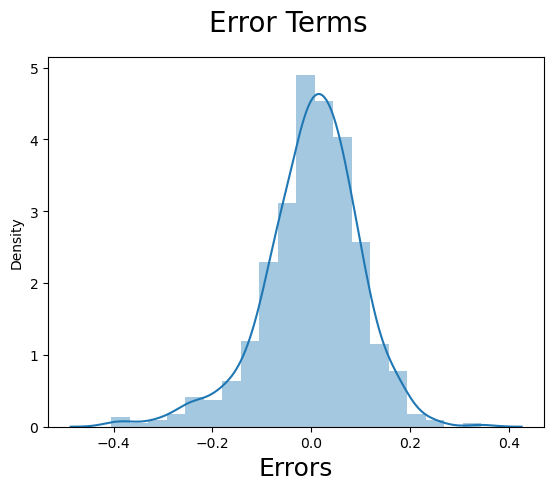

In [180]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((y_train_df - y_train_pred), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)                         # X-label

## Error term is normally distributed around 0

# Evaluate model on test data and make Predictions

In [181]:
X_train_rfe_df.columns

Index(['yr', 'temp', 'windspeed', 'season_2', 'season_4', 'mnth_9',
       'weathersit_2', 'weathersit_3'],
      dtype='object')

In [182]:
## Apply minMax scaler for non boolean columns
#cols = ['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'cnt']
new_bike_test_df[cols] = scaler.transform(new_bike_test_df[cols])

In [183]:
new_bike_test_df.describe()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,...,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,0.452055,0.013699,0.726027,0.513327,0.486680,0.617324,0.461923,0.498457,0.260274,0.226027,...,0.054795,0.123288,0.130137,0.157534,0.150685,0.123288,0.178082,0.143836,0.308219,0.013699
std,0.499409,0.116637,0.447530,0.229925,0.217533,0.143761,0.214336,0.213583,0.440294,0.419697,...,0.228362,0.329899,0.337612,0.365558,0.358973,0.329899,0.383899,0.352131,0.463347,0.116637
min,0.000000,0.000000,0.000000,0.047675,0.051010,0.193646,0.062226,0.142775,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.317742,0.306197,0.516316,0.294317,0.310084,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,0.483409,0.471301,0.601975,0.445562,0.503164,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.723272,0.677047,0.714815,0.547829,0.665526,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,0.960541,0.939531,1.002146,1.213032,0.981707,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Split X and y variables

In [184]:
y_test_df = new_bike_test_df.pop('cnt')
X_test_df = new_bike_test_df

In [185]:
X_test_new_df = X_test_df[X_train_rfe_df.columns]

## Predict 'cnt' variable on test data set

In [186]:
X_test_new_df = sm.add_constant(X_test_new_df)
y_test_pred = lr_model7.predict(X_test_new_df)

## Evaluate Model on test data set

Text(0, 0.5, 'y_test_pred')

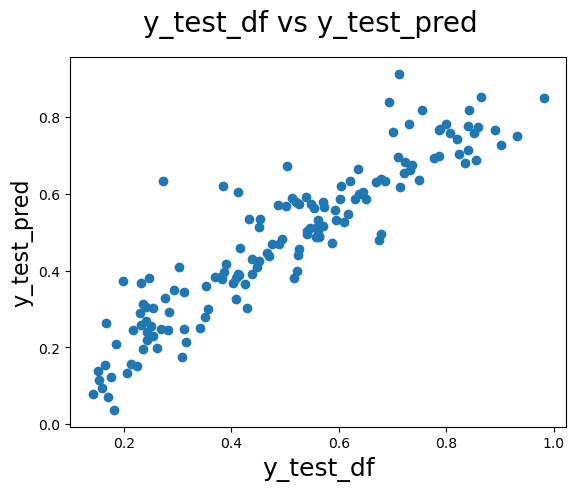

In [187]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.scatter(y_test_df,y_test_pred)
fig.suptitle('y_test_df vs y_test_pred', fontsize=20)         # Plot heading 
plt.xlabel('y_test_df', fontsize=18)                          # X-label
plt.ylabel('y_test_pred', fontsize=16)     

In [188]:
from sklearn.metrics import r2_score
print("Train data set R2 score",round(r2_score(y_train_df, y_train_pred),5))
print("Test data set R2 score",round(r2_score(y_test_df, y_test_pred),5))

Train data set R2 score 0.81101
Test data set R2 score 0.83465


## R2 score is significantly good on test data set